<a href="https://colab.research.google.com/github/CarlosBaztan/Clases-Python-UNIR/blob/main/Act2Gesti%C3%B3nPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##ACTIVIDAD 2 GESTIÓN DE PROYECTOS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga del dataset
df = pd.read_csv('dataset_provincias.csv')

# Limpieza: quitamos espacios en nombres de provincia (ej: "Granada ")
df['Provincias'] = df['Provincias'].str.strip()

# Comprobamos tipos de variables
print(df.dtypes)

Unnamed: 0       int64
Provincias      object
Year             int64
Mes              int64
dia              int64
fecha           object
Población        int64
Unidades       float64
Euros          float64
precio         float64
UdesxCapita    float64
dtype: object


In [ ]:
#Estadísticos descriptivos
df.describe()

,Unnamed: 0,Year,Mes,dia,Población,Unidades,Euros,precio,UdesxCapita
count,9792.000000,9792.00000,9792.000000,9792.0,9.792000e+03,9.792000e+03,9.792000e+03,9792.000000,9792.000000
mean,4896.500000,2013.00000,6.500000,15.0,7.789071e+05,5.281778e+06,1.834027e+07,3.751743,6.988419
std,2826.851252,4.89923,3.452229,0.0,9.804654e+05,6.612474e+06,2.148203e+07,0.894846,3.667182
min,1.000000,2005.00000,1.000000,15.0,8.166100e+04,2.415150e+05,9.771371e+05,1.885948,2.098204
25%,2448.750000,2009.00000,3.750000,15.0,3.070105e+05,1.646447e+06,5.973650e+06,2.689243,4.684116
50%,4896.500000,2013.00000,6.500000,15.0,5.141170e+05,3.196861e+06,1.213809e+07,4.294138,5.847241
75%,7344.250000,2017.00000,9.250000,15.0,8.406895e+05,5.895038e+06,2.015939e+07,4.505099,8.395733
max,9792.000000,2021.00000,12.000000,15.0,5.737647e+06,5.309835e+07,1.413866e+08,4.694374,60.294515


In [ ]:
#Comprobar que los nombres de provincia se leen bien
print(df['Provincias'].unique())

['Álava' 'Albacete' 'Alicante/Alacant' 'Almería' 'Asturias' 'Ávila'
 'Badajoz' 'Balears (Illes)' 'Barcelona' 'Burgos' 'Cáceres' 'Cádiz'
 'Cantabria' 'Castellón/Castelló' 'Ciudad Real' 'Córdoba' 'Coruña (A)'
 'Cuenca' 'Girona' 'Granada' 'Guadalajara' 'Guipúzcoa' 'Huelva' 'Huesca'
 'Jaén' 'León' 'Lleida' 'Lugo' 'Madrid' 'Málaga' 'Murcia' 'Navarra'
 'Ourense' 'Palencia' 'Pontevedra' 'Rioja (La)' 'Salamanca' 'Segovia'
 'Sevilla' 'Soria' 'Tarragona' 'Teruel' 'Toledo' 'Valencia/València'
 'Valladolid' 'Vizcaya' 'Zamora' 'Zaragoza']


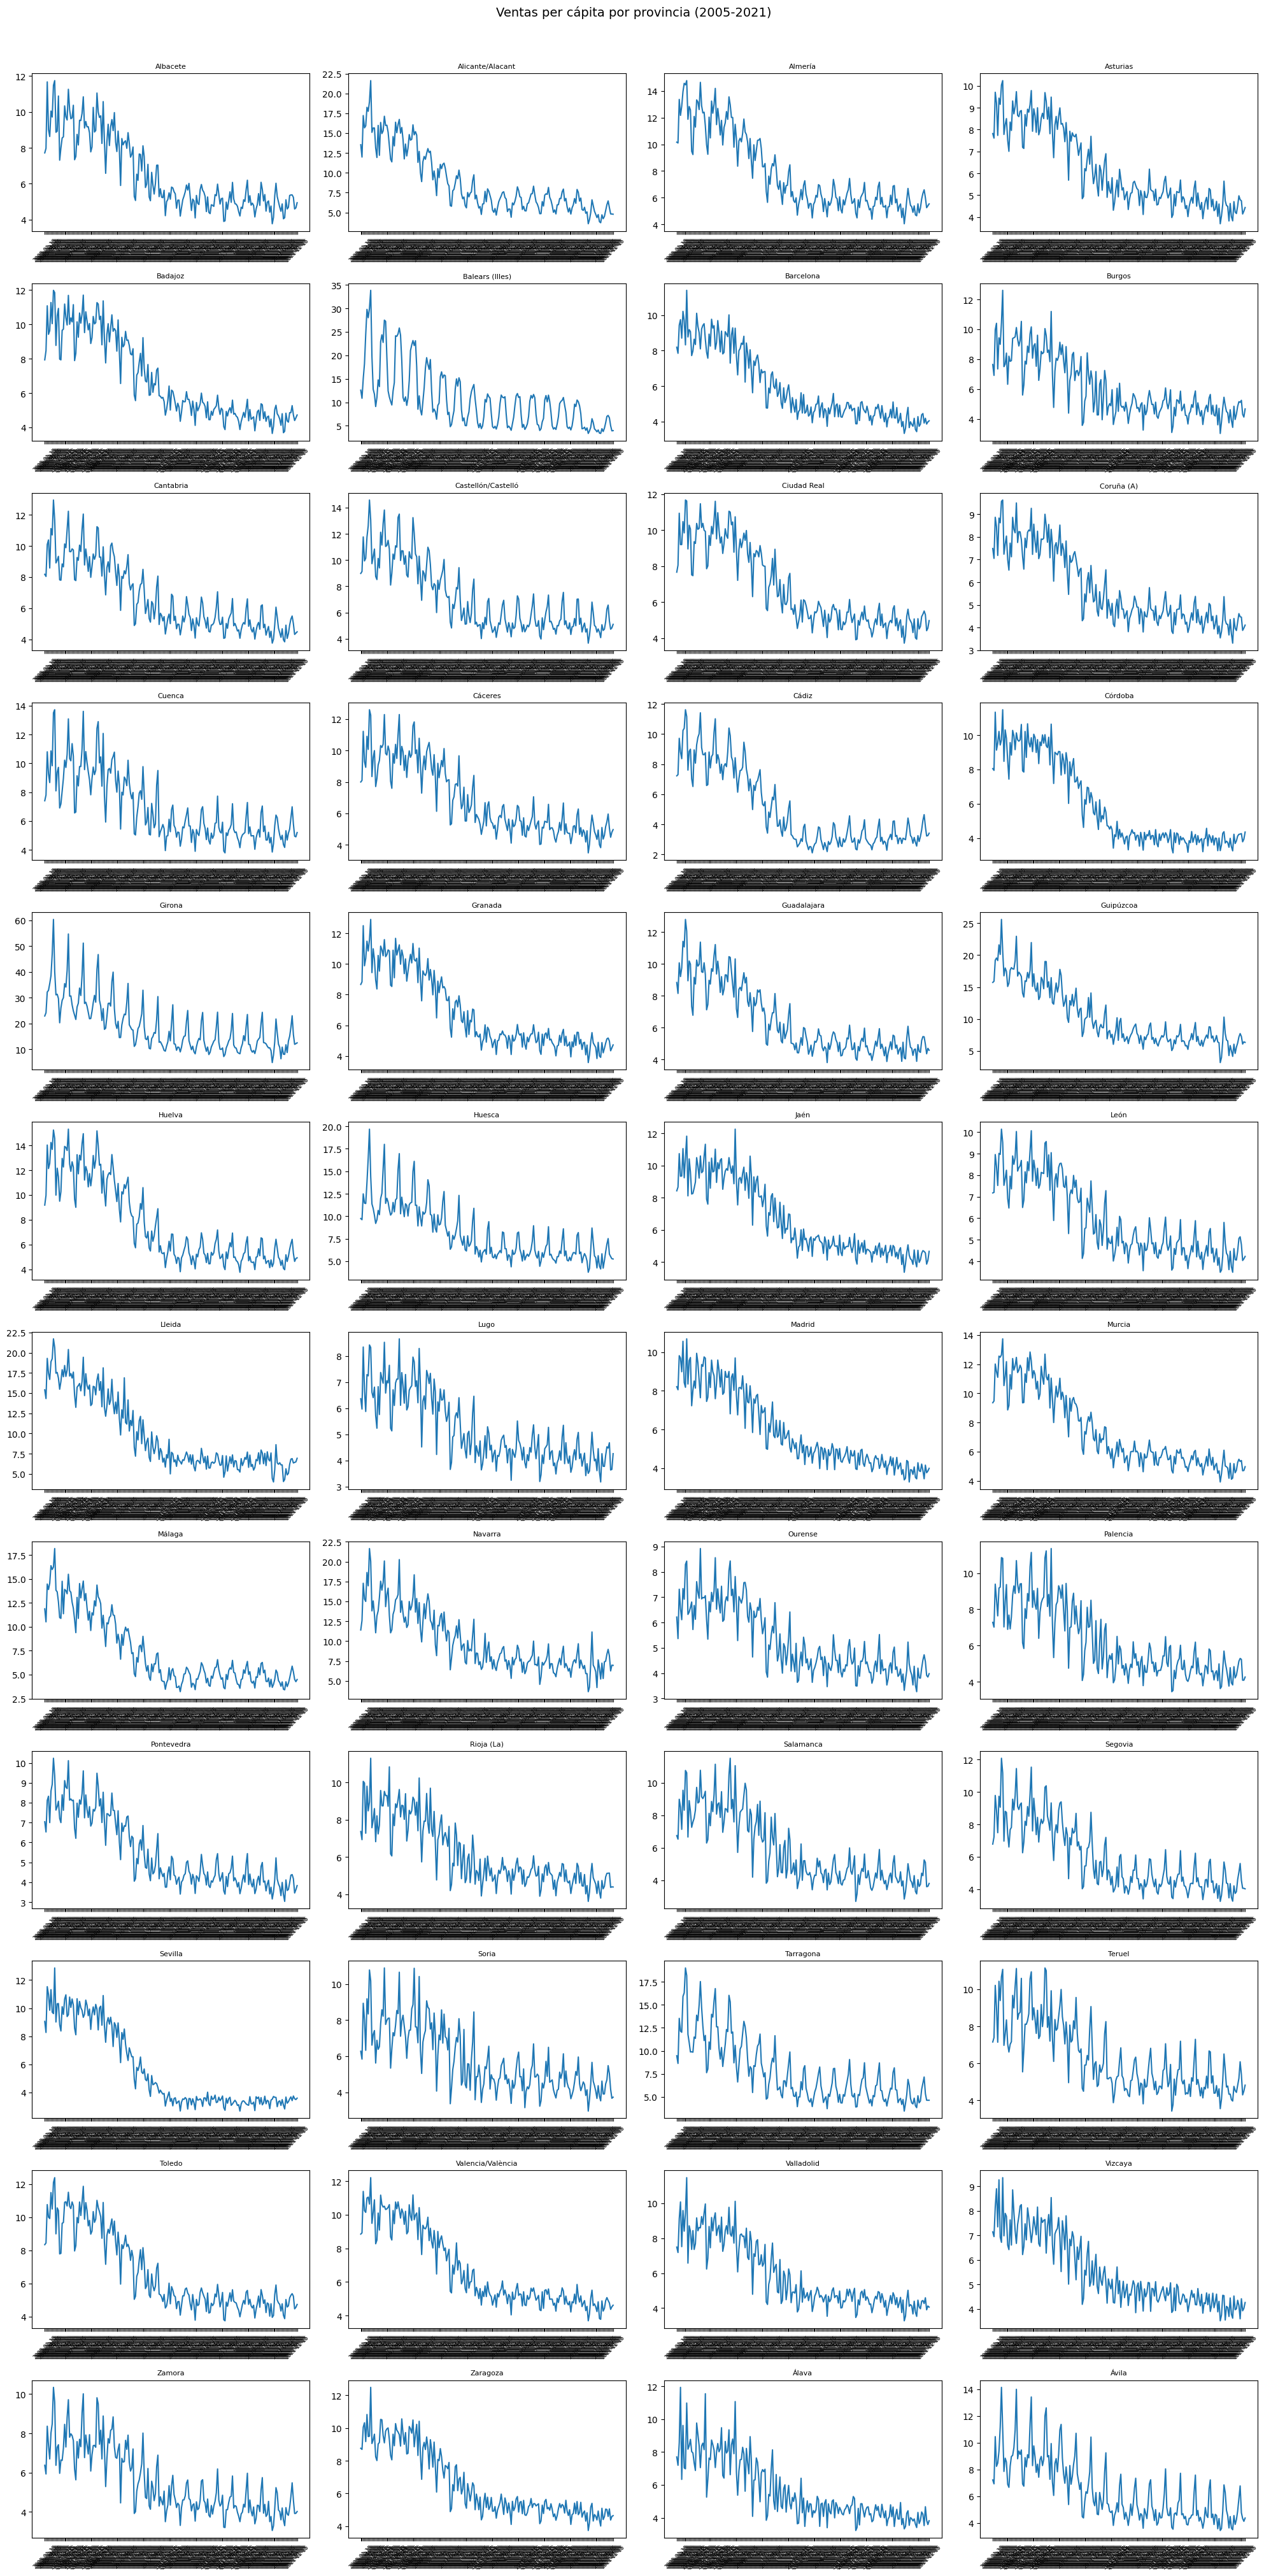

In [ ]:
provincias = sorted(df['Provincias'].unique())

fig, axes = plt.subplots(nrows=12, ncols=4, figsize=(20, 40))
axes = axes.flatten()

for i, prov in enumerate(provincias):
    datos_prov = df[df['Provincias'] == prov]
    axes[i].plot(datos_prov['fecha'], datos_prov['UdesxCapita'])
    axes[i].set_title(prov, fontsize=8)
    axes[i].tick_params(axis='x', rotation=45, labelsize=6)

# Ocultamos los subgráficos que sobren
for j in range(len(provincias), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Ventas per cápita por provincia (2005-2021)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

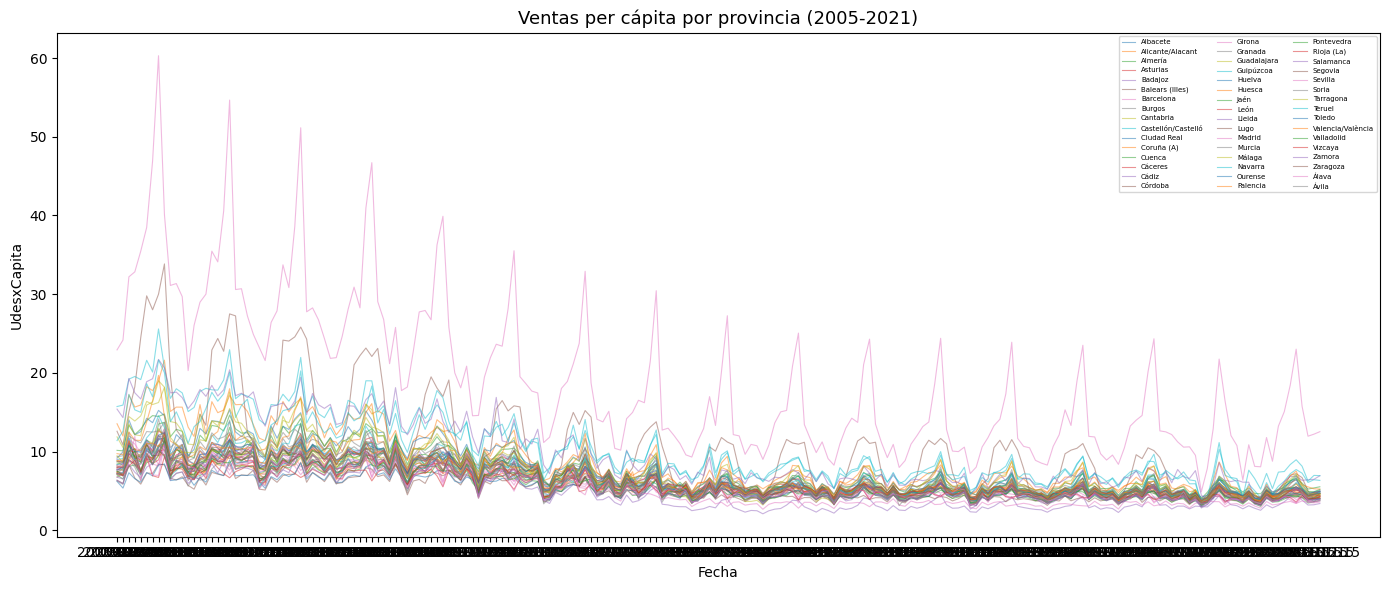

In [ ]:
provincias = sorted(df['Provincias'].unique())

fig, ax = plt.subplots(figsize=(14, 6))

for prov in provincias:
    datos_prov = df[df['Provincias'] == prov]
    ax.plot(datos_prov['fecha'], datos_prov['UdesxCapita'],
            linewidth=0.8, alpha=0.5, label=prov)

ax.set_title('Ventas per cápita por provincia (2005-2021)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('UdesxCapita')
ax.legend(fontsize=5, ncol=3, loc='upper right')
plt.tight_layout()
plt.show()

Pregunta 2

In [ ]:
import matplotlib.pyplot as plt

# Media de ventas per cápita por provincia
ranking = df.groupby('Provincias')['UdesxCapita'].mean()

# Ordenar de mayor a menor
ranking = ranking.sort_values(ascending=False)

# Ver ranking
ranking

,UdesxCapita
Provincias,
Girona,18.983785
Balears (Illes),10.480479
Guipúzcoa,10.361764
Lleida,9.927587
Navarra,9.902648
Alicante/Alacant,8.805555
Huesca,8.068748
Almería,7.845694
Tarragona,7.716149


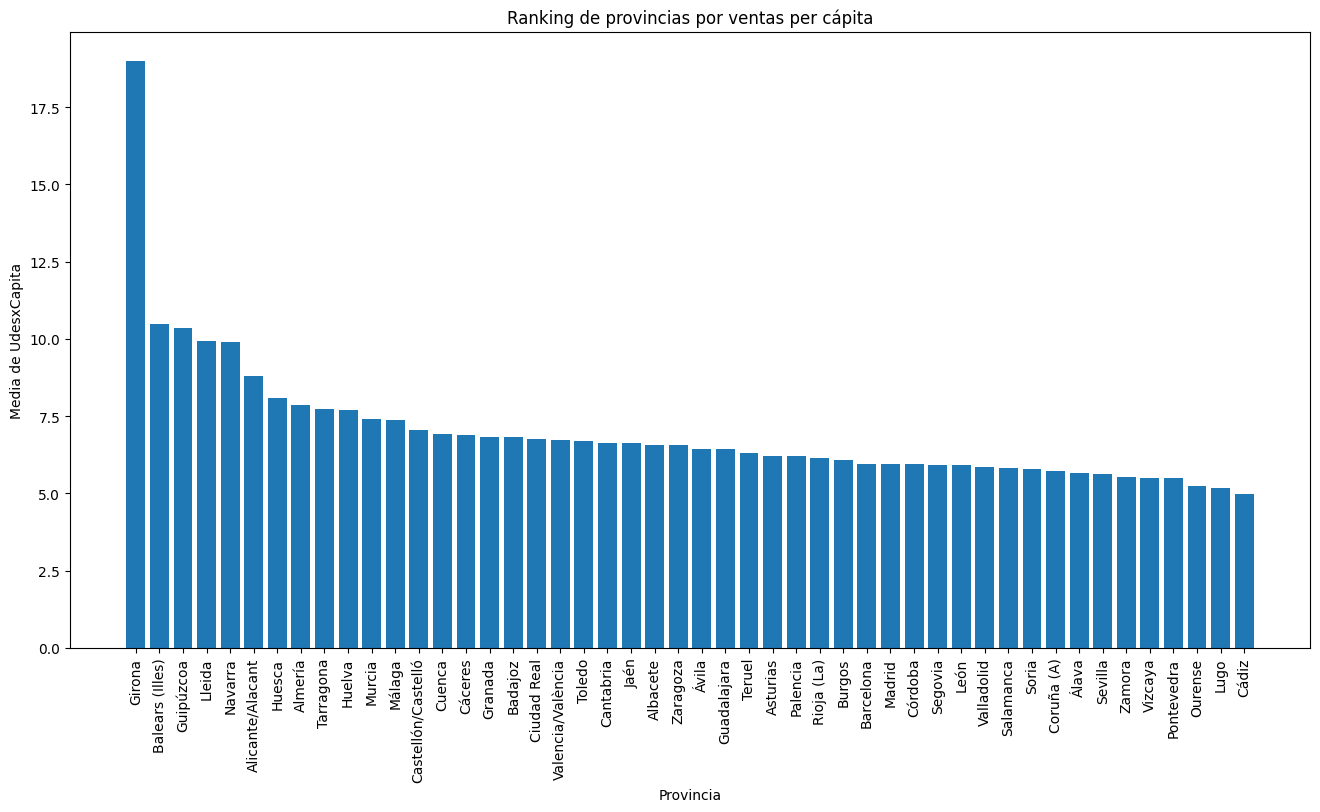

In [ ]:
plt.figure(figsize=(16,8))

plt.bar(ranking.index, ranking.values)

plt.title('Ranking de provincias por ventas per cápita')
plt.xlabel('Provincia')
plt.ylabel('Media de UdesxCapita')

plt.xticks(rotation=90)

plt.show()

Preguta 3

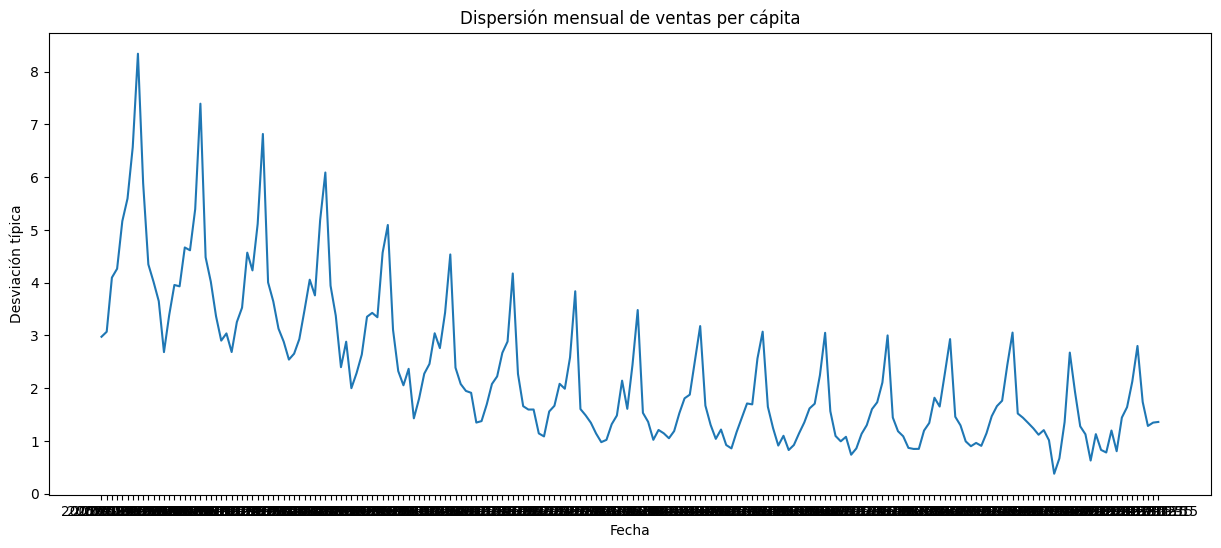

In [ ]:
dispersion = df.groupby('fecha')['UdesxCapita'].std()

plt.figure(figsize=(15,6))
plt.plot(dispersion)

plt.title('Dispersión mensual de ventas per cápita')
plt.xlabel('Fecha')
plt.ylabel('Desviación típica')

plt.show()

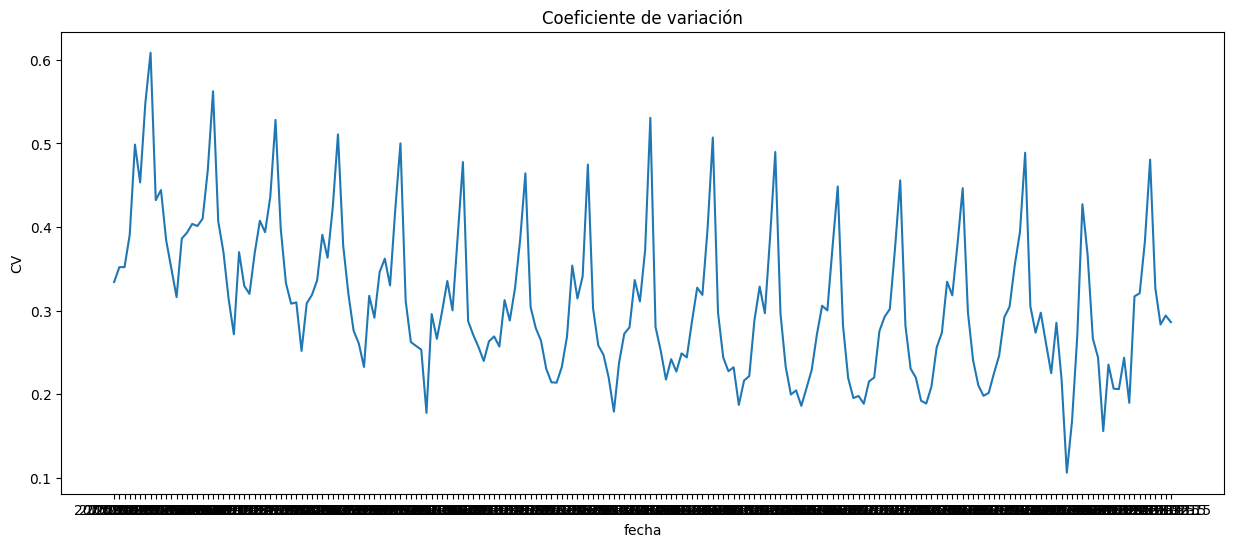

In [ ]:
media = df.groupby('fecha')['UdesxCapita'].mean()
desv = df.groupby('fecha')['UdesxCapita'].std()

cv = desv / media

plt.figure(figsize=(15,6))
plt.plot(cv)

plt.title('Coeficiente de variación')
plt.xlabel('fecha')
plt.ylabel('CV')

plt.show()

Pregunta 4

In [ ]:
ranking = df.groupby('Provincias')['UdesxCapita'].mean().sort_values(ascending=False)

ranking

,UdesxCapita
Provincias,
Girona,18.983785
Balears (Illes),10.480479
Guipúzcoa,10.361764
Lleida,9.927587
Navarra,9.902648
Alicante/Alacant,8.805555
Huesca,8.068748
Almería,7.845694
Tarragona,7.716149


In [ ]:
club1 = ranking[ranking >= ranking.quantile(0.75)]
club2 = ranking[(ranking < ranking.quantile(0.75)) & (ranking >= ranking.quantile(0.50))]
club3 = ranking[(ranking < ranking.quantile(0.50)) & (ranking >= ranking.quantile(0.25))]
club4 = ranking[ranking < ranking.quantile(0.25)]

print("CLUB 1")
print(club1)

print("\nCLUB 2")
print(club2)

print("\nCLUB 3")
print(club3)

print("\nCLUB 4")
print(club4)

CLUB 1
Provincias
Girona              18.983785
Balears (Illes)     10.480479
Guipúzcoa           10.361764
Lleida               9.927587
Navarra              9.902648
Alicante/Alacant     8.805555
Huesca               8.068748
Almería              7.845694
Tarragona            7.716149
Huelva               7.703483
Murcia               7.415463
Málaga               7.370576
Name: UdesxCapita, dtype: float64

CLUB 2
Provincias
Castellón/Castelló    7.050350
Cuenca                6.922934
Cáceres               6.886201
Granada               6.825114
Badajoz               6.820889
Ciudad Real           6.751626
Valencia/València     6.727983
Toledo                6.686319
Cantabria             6.635647
Jaén                  6.612618
Albacete              6.573920
Zaragoza              6.558949
Name: UdesxCapita, dtype: float64

CLUB 3
Provincias
Ávila          6.422929
Guadalajara    6.422614
Teruel         6.306450
Asturias       6.197203
Palencia       6.192092
Rioja (La)     6.152386


Pregunta 5

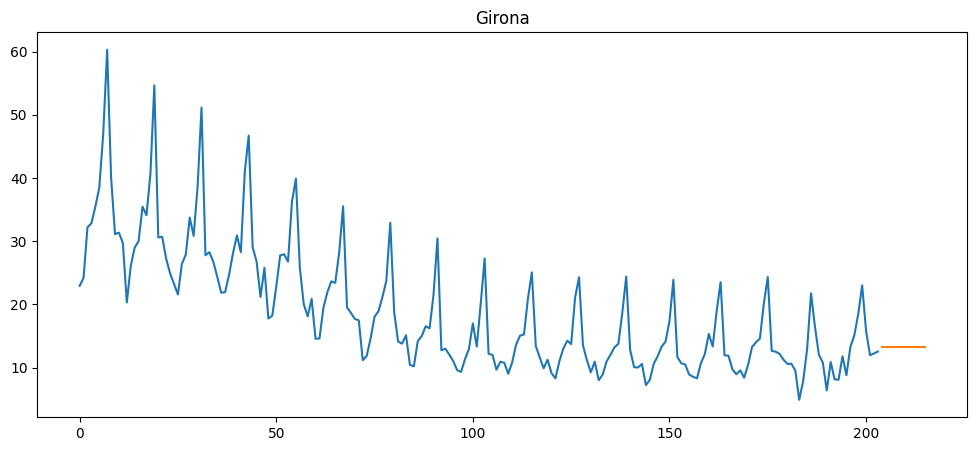

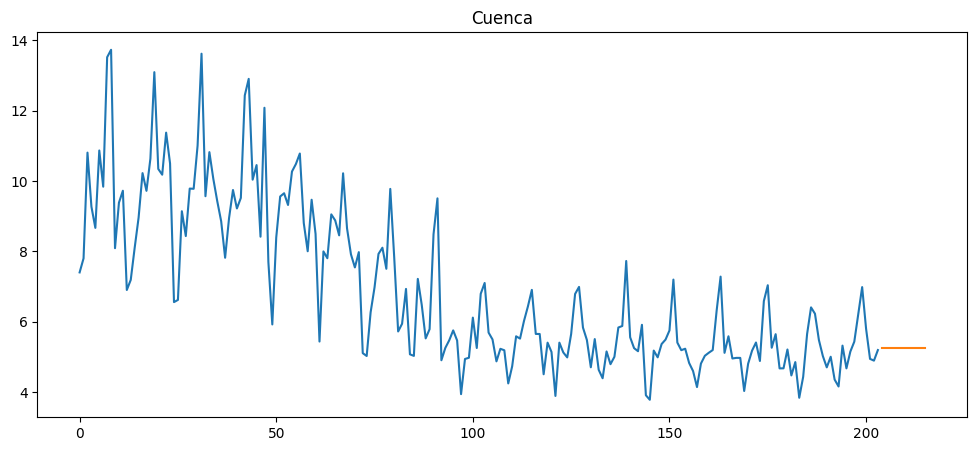

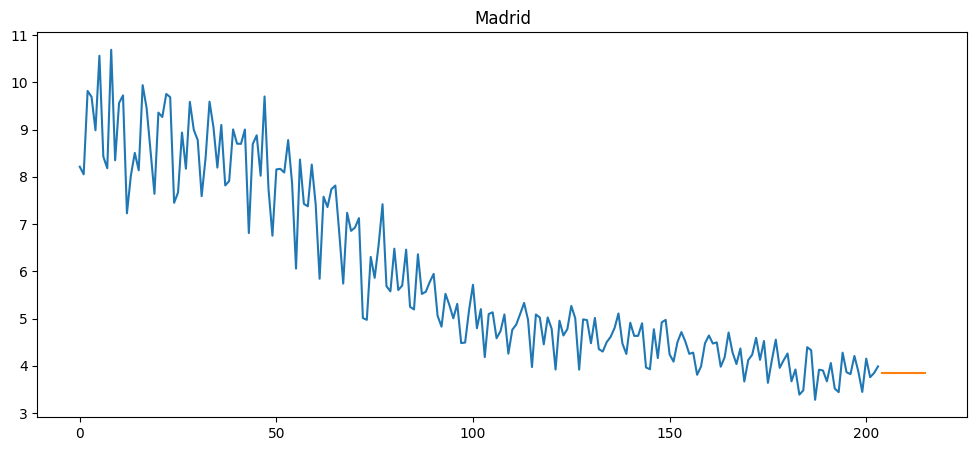

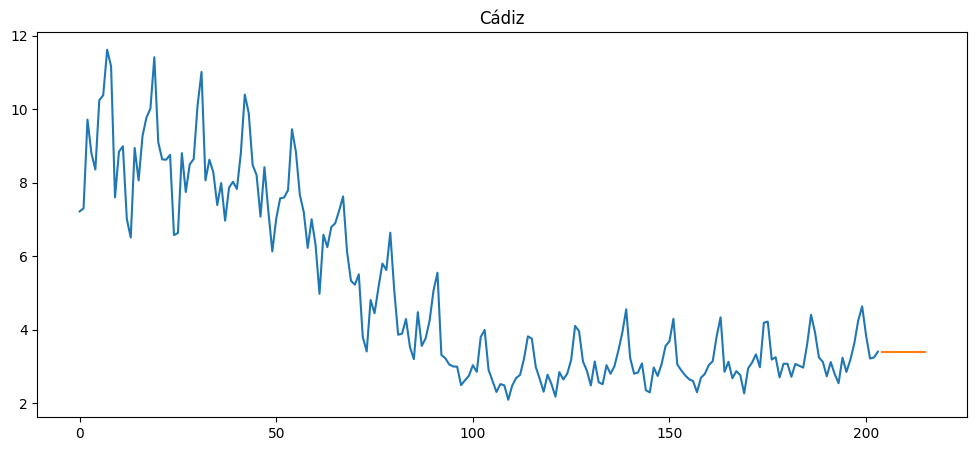

In [ ]:
provincias = ['Girona','Cuenca','Madrid','Cádiz']

for provincia in provincias:

    datos = df[df['Provincias']==provincia].copy()
    datos = datos.sort_values('fecha')

    serie = datos['UdesxCapita']

    pred = serie.tail(12).mean()
    prediccion = [pred]*12

    plt.figure(figsize=(12,5))
    plt.plot(serie.values)
    plt.plot(range(len(serie), len(serie)+12), prediccion)
    plt.title(provincia)
    plt.show()